## Understanding Logistic Regression

Logistic Regression is a powerful and widely used statistical method for **binary classification** tasks. Despite its name, it's used for classification, not regression, as it predicts the probability of an instance belonging to a particular class. If the probability is above a certain threshold (e.g., 0.5), it assigns the instance to one class; otherwise, it assigns it to the other.

### How it Works:

1.  **Linear Combination**: Like linear regression, logistic regression starts by calculating a linear combination of the input features and their corresponding weights (and a bias term).
    $$z = w_0 + w_1x_1 + w_2x_2 + ... + w_nx_n$$
    Where $z$ is the input to the activation function, $w_i$ are the weights, and $x_i$ are the features.

2.  **Sigmoid Function (Logistic Function)**: Instead of outputting $z$ directly, logistic regression passes $z$ through a **sigmoid (or logistic) function**. This function squashes the output of the linear equation into a probability score between 0 and 1.
    $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
    The output of the sigmoid function, $\sigma(z)$, can be interpreted as the probability of the instance belonging to the positive class (e.g., P(Y=1|X)).

    *   If $z$ is large and positive, $\sigma(z)$ approaches 1.
    *   If $z$ is large and negative, $\sigma(z)$ approaches 0.
    *   If $z$ is 0, $\sigma(z)$ is 0.5.

3.  **Decision Boundary**: A threshold (commonly 0.5) is applied to these probabilities to make a final classification decision:
    *   If $\sigma(z) \geq 0.5$, predict class 1 (positive).
    *   If $\sigma(z) < 0.5$, predict class 0 (negative).

### Why not Linear Regression for Classification?

Linear regression outputs a continuous value, which isn't ideal for classification tasks where we need discrete class labels. Using a threshold on linear regression output can lead to issues, especially with outliers, as it doesn't constrain the output to probabilities.

### Key Advantages:

*   **Simplicity and Interpretability**: Easy to understand and implement. The coefficients can be interpreted in terms of the odds ratio.
*   **Efficiency**: Relatively fast to train, especially on large datasets.
*   **Probabilistic Output**: Provides probabilities, which can be useful for ranking predictions or setting custom decision thresholds.

### Applications:

*   Spam detection (spam vs. not spam)
*   Disease prediction (diseased vs. healthy)
*   Customer churn prediction (churn vs. not churn)
*   Credit scoring (good risk vs. bad risk)

## Logistic Regression Coding Example

Let's implement a simple logistic regression model using `scikit-learn` in Python. We'll generate some synthetic data for a binary classification problem.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import make_classification # For creating synthetic data

print('Libraries imported successfully.')

Libraries imported successfully.


### 1. Generate Synthetic Data

We'll create a dataset with two features and two classes using `make_classification`.

Training data shape: (700, 2)
Testing data shape: (300, 2)
Labels distribution in training: [354 346]
Labels distribution in testing: [147 153]


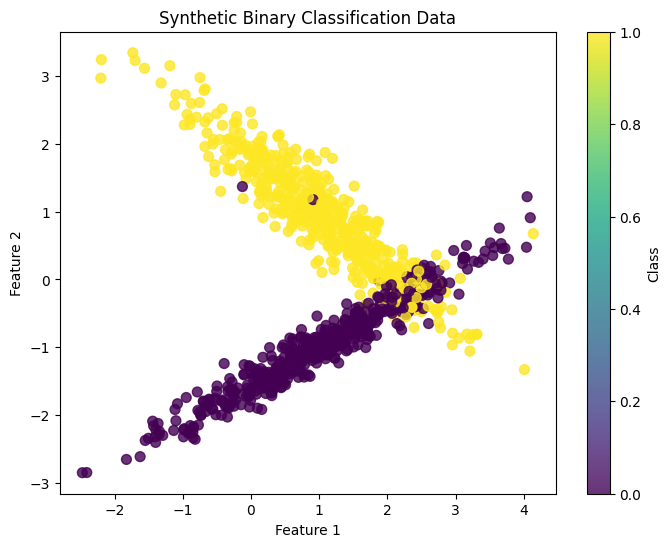

In [3]:
# Generate synthetic dataset
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")
print(f"Labels distribution in training: {np.bincount(y_train)}")
print(f"Labels distribution in testing: {np.bincount(y_test)}")

# Visualize the data
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', s=50, alpha=0.8)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Synthetic Binary Classification Data')
plt.colorbar(label='Class')
plt.show()

### 2. Initialize and Train the Logistic Regression Model

Now, we'll create an instance of `LogisticRegression` and fit it to our training data. The `fit` method handles the process of finding the optimal weights ($w_i$) that minimize the cost function (typically cross-entropy for logistic regression).

In [4]:
# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")
print(f"Model coefficients (weights): {model.coef_[0]}")
print(f"Model intercept (bias): {model.intercept_[0]}")

Logistic Regression model trained successfully.
Model coefficients (weights): [-0.72336264  3.54855707]
Model intercept (bias): 1.5299511295028083


### 3. Make Predictions and Evaluate the Model

After training, we use the model to make predictions on the unseen test data. We then evaluate its performance using metrics like accuracy, confusion matrix, and a classification report.


Accuracy: 0.88

Confusion Matrix:
[[137  10]
 [ 25 128]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       147
           1       0.93      0.84      0.88       153

    accuracy                           0.88       300
   macro avg       0.89      0.88      0.88       300
weighted avg       0.89      0.88      0.88       300



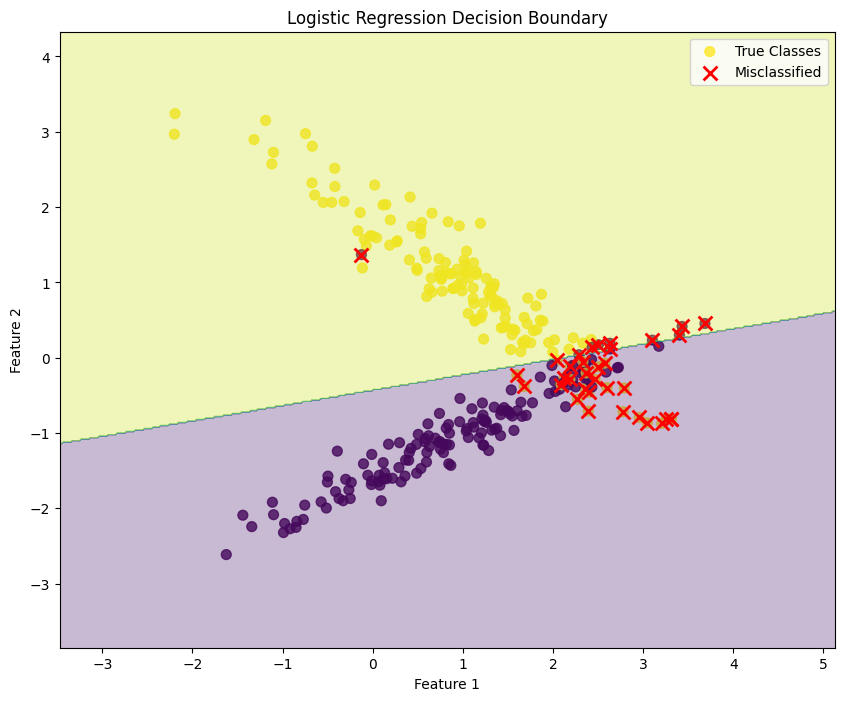

In [5]:
# Make predictions on the test set
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probabilities of the positive class

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.2f}")
print(f"\nConfusion Matrix:\n{conf_matrix}")
print(f"\nClassification Report:\n{class_report}")

# Visualize the decision boundary (for 2D data)
plt.figure(figsize=(10, 8))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', s=50, alpha=0.8, label='True Classes')

# Plot the decision boundary
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

plt.scatter(X_test[y_test != y_pred, 0], X_test[y_test != y_pred, 1],
            marker='x', s=100, color='red', linewidths=2, label='Misclassified')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

### Interpretation of Results:

*   **Accuracy**: The proportion of correctly classified instances.
*   **Confusion Matrix**: Shows the number of true positives, true negatives, false positives, and false negatives.
    *   `[[True Negative, False Positive], [False Negative, True Positive]]`
*   **Classification Report**: Provides precision, recall, and F1-score for each class, which are useful metrics, especially for imbalanced datasets.

This example demonstrates the fundamental steps of applying logistic regression for a binary classification task, from data generation and training to prediction and evaluation.